# Deep Learning Model (Checkpoint 5)
This notebook builds and evaluates an LSTM sentiment classifier using the same cleaned dataset and split policy as earlier checkpoints.

**1. Setup and reusable imports**  
Load split data and helper functions from `src/` using module reload so notebook changes are reflected without restarting the kernel.

Why this step matters:
- Reusing `src/` logic keeps checkpoints consistent and avoids duplicated code drift.
- Reloading modules makes iterative debugging safer in long notebook sessions.
- Confirming the Python executable helps verify we are running on the project `.venv`.

What we are trying to learn:
- Whether the experiment environment and data pipeline are stable before training starts.

In [23]:
import importlib
import sys
from pathlib import Path
from joblib import dump

import matplotlib.pyplot as plt
import pandas as pd

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import src.config as config_module
import src.data_loader as data_loader_module
import src.features as features_module
import src.dl_model as dl_model_module

config_module = importlib.reload(config_module)
data_loader_module = importlib.reload(data_loader_module)
features_module = importlib.reload(features_module)
dl_model_module = importlib.reload(dl_model_module)

FIGURES_DIR = config_module.FIGURES_DIR
RESULTS_DIR = config_module.RESULTS_DIR
get_splits = data_loader_module.get_splits
get_tokenized_padded_sequences = features_module.get_tokenized_padded_sequences
build_lstm_model = dl_model_module.build_lstm_model
train_lstm_model = dl_model_module.train_lstm_model
evaluate_lstm_model = dl_model_module.evaluate_lstm_model
plot_training_history = dl_model_module.plot_training_history

print('Python executable:', sys.executable)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
metrics_dir = RESULTS_DIR / 'metrics'
metrics_dir.mkdir(parents=True, exist_ok=True)
models_dir = project_root / 'models'
models_dir.mkdir(parents=True, exist_ok=True)

X_train_text, y_train, X_val_text, y_val, X_test_text, y_test = get_splits(verbose=True)
print('Train size:', X_train_text.shape[0])
print('Val size  :', X_val_text.shape[0])
print('Test size :', X_test_text.shape[0])

Python executable: c:\projects\imdb-sentiment-analysis\.venv\Scripts\python.exe
Loaded 50,000 rows from preprocessed IMDB dataset.
Split sizes:
  train: 34,999 (70%)
  val  :  7,501 (15%)
  test :  7,500 (15%)
Label distribution (positive class count):
  train: 17,500 / 34,999
  val  :  3,750 / 7,501
  test :  3,750 / 7,500
Train size: 34999
Val size  : 7501
Test size : 7500


**2. Tokenize and pad text for LSTM**  
Unlike TF-IDF, LSTM models consume integer token sequences of fixed length.

Why this step matters:
- Tokenization maps words to indices so neural layers can learn distributed representations.
- Padding/truncation creates uniform shapes required by mini-batch training.
- Fitting the tokenizer on train only avoids leakage from validation/test text.

What we are trying to learn:
- Whether the sequence representation preserves enough sentiment signal for deep learning.

In [24]:
tokenized = get_tokenized_padded_sequences(
    X_train_text,
    X_val_text,
    X_test_text,
    num_words=20_000,
    max_sequence_length=300,
)

X_train_dl = tokenized['train']
X_val_dl = tokenized['val']
X_test_dl = tokenized['test']
vocab_size = tokenized['vocab_size']
max_sequence_length = tokenized['max_sequence_length']

print('Train sequence shape:', X_train_dl.shape)
print('Val sequence shape  :', X_val_dl.shape)
print('Test sequence shape :', X_test_dl.shape)
print('Vocab size used     :', vocab_size)
print('Max sequence length :', max_sequence_length)

Train sequence shape: (34999, 300)
Val sequence shape  : (7501, 300)
Test sequence shape : (7500, 300)
Vocab size used     : 20000
Max sequence length : 300


**3. Build the LSTM architecture**  
Baseline architecture: `Embedding -> LSTM -> Dropout -> Sigmoid` for binary sentiment prediction.

Why this step matters:
- The embedding layer learns dense word vectors from this corpus.
- The LSTM captures token order and short/medium-range context.
- Dropout regularizes the model to reduce overfitting risk.

What we are trying to learn:
- Whether a compact LSTM can outperform or complement classic sparse-feature baselines.

In [25]:
lstm_model = build_lstm_model(
    vocab_size=vocab_size,
    max_sequence_length=max_sequence_length,
    embedding_dim=128,
    lstm_units=128,
    dropout_rate=0.3,
    learning_rate=1e-3,
)

lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 300, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,691,713 (10.27 MB)

 Trainable params: 2,691,713 (10.27 MB)

 Non-trainable params: 0 (0.00 B)

**4. Train with early stopping**  
Train for up to 10 epochs while monitoring validation loss and restoring the best weights.

How to interpret this result:
- `epochs=10` is a maximum limit, not a guaranteed number of completed epochs.
- With `patience=2`, training stops after two consecutive epochs without validation-loss improvement.
- If the best validation loss occurs early, training can end at epoch 4 and restore the earlier best checkpoint.

What we are trying to learn:
- Whether optimization is converging and where generalization starts to degrade.

In [26]:
best_model_path = models_dir / 'lstm_best.keras'
history = train_lstm_model(
    model=lstm_model,
    X_train=X_train_dl,
    y_train=y_train,
    X_val=X_val_dl,
    y_val=y_val,
    batch_size=128,
    epochs=10,
    patience=2,
    monitor='val_loss',
    mode='min',
    min_delta=1e-4,
    model_path=best_model_path,
    verbose=1,
)

history_df = pd.DataFrame(history.history)
print(f"Epochs completed: {len(history_df)} / 10")
print(f"Best validation-loss epoch: {int(history_df['val_loss'].idxmin()) + 1}")
history_df

Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 253s 913ms/step - accuracy: 0.7630 - loss: 0.5047 - val_accuracy: 0.8530 - val_loss: 0.3465
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 275s 1s/step - accuracy: 0.9181 - loss: 0.2231 - val_accuracy: 0.8804 - val_loss: 0.2983
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 261s 952ms/step - accuracy: 0.9473 - loss: 0.1515 - val_accuracy: 0.8630 - val_loss: 0.3534
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 258s 940ms/step - accuracy: 0.9650 - loss: 0.1066 - val_accuracy: 0.8708 - val_loss: 0.3836
Epochs completed: 4 / 10
Best validation-loss epoch: 2


,accuracy,loss,val_accuracy,val_loss
0,0.831852,0.395547,0.852953,0.346547
1,0.917083,0.223189,0.880416,0.298345
2,0.942170,0.159609,0.862952,0.353361
3,0.955970,0.124774,0.870817,0.383584


**5. Evaluate on validation and test**  
Validation metrics guide diagnosis and tuning decisions; test metrics are the final unbiased checkpoint report.

How to interpret this result:
- Balanced metrics (accuracy, precision, recall, F1) suggest stable class behavior.
- Very high recall with near-random accuracy usually indicates over-prediction of the positive class.
- Validation and test should be directionally similar if the split policy and model behavior are stable.

What we are trying to learn:
- Whether this baseline LSTM generalizes meaningfully beyond the training split.

In [27]:
val_metrics, y_val_pred, y_val_prob = evaluate_lstm_model(lstm_model, X_val_dl, y_val)
test_metrics, y_test_pred, y_test_prob = evaluate_lstm_model(lstm_model, X_test_dl, y_test)

dl_metrics_df = pd.DataFrame([
    {'model': 'LSTM', 'split': 'validation', **val_metrics},
    {'model': 'LSTM', 'split': 'test', **test_metrics},
])

dl_metrics_path = metrics_dir / 'dl_lstm_metrics.csv'
dl_metrics_df.to_csv(dl_metrics_path, index=False)
print(f'Saved -> {dl_metrics_path}')
dl_metrics_df

Saved -> C:\projects\imdb-sentiment-analysis\results\metrics\dl_lstm_metrics.csv


,model,split,accuracy,precision,recall,f1
0,LSTM,validation,0.880416,0.880299,0.880533,0.880416
1,LSTM,test,0.883333,0.880795,0.886667,0.883721


**6. Diagnose prediction behavior**  
This section explains weak aggregate metrics by checking class prediction tendency and threshold sensitivity.

How to interpret this result:
- A very high predicted-positive rate usually explains high recall but poor precision/accuracy.
- Confusion matrices show *where* errors happen (false positives vs false negatives).
- Threshold sweeps reveal whether poor performance is mostly a calibration issue or a representation/model issue.

What we are trying to learn:
- Whether this run failed because of class bias, threshold choice, or broader underfitting.

In [28]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score

def summarize_split(name, y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{name} diagnostics")
    print("-" * (len(name) + 12))
    print(f"Predicted positive rate: {y_pred.mean():.3f}")
    print(f"Mean predicted probability: {y_prob.mean():.3f}")
    print("Confusion matrix [ [TN, FP], [FN, TP] ]:")
    print(cm)
    return {"tn": tn, "fp": fp, "fn": fn, "tp": tp}

_ = summarize_split("Validation", y_val, y_val_pred, y_val_prob)
_ = summarize_split("Test", y_test, y_test_pred, y_test_prob)

threshold_rows = []
for thr in np.arange(0.1, 0.91, 0.05):
    y_val_thr = (y_val_prob >= thr).astype(int)
    threshold_rows.append(
        {
            "threshold": round(float(thr), 2),
            "val_accuracy": accuracy_score(y_val, y_val_thr),
            "val_precision": precision_score(y_val, y_val_thr, zero_division=0),
            "val_recall": recall_score(y_val, y_val_thr, zero_division=0),
            "val_f1": f1_score(y_val, y_val_thr, zero_division=0),
        }
    )

threshold_df = pd.DataFrame(threshold_rows).sort_values("val_f1", ascending=False)
best_threshold = float(threshold_df.iloc[0]["threshold"])
print(f"\nBest validation F1 threshold in sweep: {best_threshold:.2f}")
threshold_df.head(10)


Validation diagnostics
----------------------
Predicted positive rate: 0.500
Mean predicted probability: 0.499
Confusion matrix [ [TN, FP], [FN, TP] ]:
[[3302  449]
 [ 448 3302]]

Test diagnostics
----------------
Predicted positive rate: 0.503
Mean predicted probability: 0.502
Confusion matrix [ [TN, FP], [FN, TP] ]:
[[3300  450]
 [ 425 3325]]

Best validation F1 threshold in sweep: 0.35


,threshold,val_accuracy,val_precision,val_recall,val_f1
5,0.35,0.878150,0.853440,0.913067,0.882247
4,0.30,0.875750,0.842489,0.924267,0.881485
6,0.40,0.877883,0.860376,0.902133,0.880760
8,0.50,0.880416,0.880299,0.880533,0.880416
3,0.25,0.872150,0.830922,0.934400,0.879628
9,0.55,0.880683,0.889495,0.869333,0.879299
7,0.45,0.877350,0.868874,0.888800,0.878724
2,0.20,0.868284,0.819972,0.943733,0.877511
10,0.60,0.876416,0.893724,0.854400,0.873620
11,0.65,0.877083,0.904000,0.843733,0.872828


**7. Plot training curves**  
Inspect train/validation trajectories to check convergence quality and overfitting behavior.

How to interpret this result:
- If validation loss trends upward while train loss drops, generalization is worsening.
- Flat accuracy near chance-level indicates underfitting or representation issues.
- Curves provide context for early stopping and help justify tuning choices in the report.

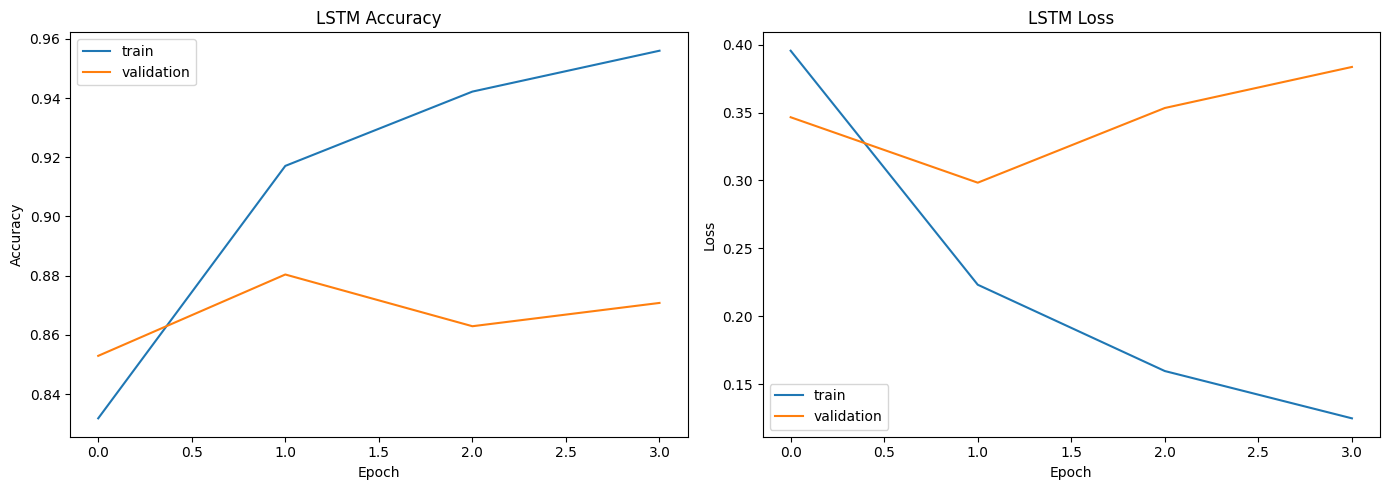

Saved -> C:\projects\imdb-sentiment-analysis\results\figures\lstm_training_history.png


In [29]:
history_fig = plot_training_history(history)
history_plot_path = FIGURES_DIR / 'lstm_training_history.png'
history_fig.savefig(history_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {history_plot_path}')

**8. Save reusable deep-learning artifacts**  
Persist tokenizer and final model so checkpoint 6 comparisons and report figures are reproducible.

Why this step matters:
- Saved artifacts enable deterministic re-evaluation without retraining.
- The tokenizer is part of the model pipeline and must be versioned with the model.
- Reproducible artifacts make debugging and report generation much easier.

In [30]:
tokenizer_path = models_dir / 'tokenizer_lstm.joblib'
dump(tokenized['tokenizer'], tokenizer_path)

final_model_path = models_dir / 'lstm_final.keras'
lstm_model.save(final_model_path)

print('Saved model/tokenizer artifacts:')
print('-', tokenizer_path.name)
print('-', final_model_path.name)

Saved model/tokenizer artifacts:
- tokenizer_lstm.joblib
- lstm_final.keras
